# Inspecting general roll outs

Visualize the expeirment: "general_rollout" (see experiment.py)

We want to validate that our generic opro roll out strategies more or less approximate "brand name" evolutionary search algorithms (e.g., gepa, open_evolve).

- Visualize score evolution over time
- visualize diversity of discovered solutions overtime.

1st visual: 
- 3x6 figure. Columns are tasks (kernelbench, cloudcast, cantbelate, harmbench, prompt+gsm8k, prompt+drop). 
- first row: scatter plot of all 14 different solutions w/ a line connecting the pareto-front of each one. Have the opro variants be shown in various shades of dimmed out blues, let gepa/open_evolve have brighter colors.
- second row: plot an average mean over the max scores across all 14 different optimizers, w/ lighter trajectories for the spread of the max scores for the individual optimizers
- third row: plot an average mean over the scores across all 14 different optimizers, w/ lighter trajectories for the spread of the scores of individual optimizers
- The x-axis shows tokens spent, the y-axis shows score. 

2nd visual:
- do the same visual as above but for semantic diversity (use a code embedding model for code tasks 'Qodo/Qodo-Embed-1-1.5B', sentence embedding model for text tasks: 'all-MiniLM-L6-v2')
- bin diversity at each token position as the average pairwise cosine distance across the last five discovered solutions (windowed approach)


## Figure plan (restated)

**Goal**: validate that generic OPRO roll-out strategies (3 sampling strategies x 4 mutators = 12 configs) approximately recover the score-vs-compute performance of the two purpose-built "brand name" evolutionary search frameworks (GEPA, OpenEvolve) -- i.e. show OPRO isn't leaving performance on the table relative to dedicated algorithms, compared on equal token budget.

**Visual 1 -- score evolution over time**, 3x6 grid:
- Columns = task (kernelbench, cloudcast, cantbelate, harmbench, prompt+gsm8k, prompt+drop)
- Row 1: scatter of all 14 optimizer configs' solutions (score vs. tokens spent) with a pareto-front line per config; OPRO variants in dimmed blues, GEPA/OpenEvolve in brighter distinct colors. Failed/crashed-candidate sentinel scores (kernelbench, cantbelate, cloudcast) are excluded from the scatter.
- Row 2: mean of the running-max score across all 14 optimizers vs. **tokens spent**, with lighter individual-optimizer running-max trajectories underneath ("best found so far" per unit compute)
- Row 3: mean of the running-max score across all 14 optimizers vs. **iteration index** (not tokens), with lighter individual trajectories underneath -- isolates per-iteration convergence from row 2's per-token convergence (optimizers spend different amounts of tokens per iteration)
- Row 1-2 x-axis: cumulative tokens spent. Row 3 x-axis: iteration count. Y-axis: score throughout.

**Visual 2 -- semantic diversity evolution**, same 3x6 layout and rows, but Y-axis is diversity instead of score: windowed average pairwise cosine distance across the last 5 discovered solutions' embeddings (`Qodo/Qodo-Embed-1-1.5B` for code tasks, `all-MiniLM-L6-v2` for text tasks).

**Data notes**:
- Source: `long_running_solution_bank.json` per run dir under `general_rollout/` -- full chronological history, one record per real evaluation event, keyed by contiguous int id. `cumulative_tokens_spent` is strictly increasing in id order, so id order == token-spend order already (no re-sorting needed).
- No deduplication of repeated solution text (open_evolve's island model can independently re-propose identical code) -- every entry is a real eval that spent its own tokens, so it stays in the score-vs-tokens trajectory as-is.
- Two open_evolve runs (cantbelate, cloudcast) can be inflated by job restarts that resumed past their intended `num_iter` (see `_resumable_run` in `llm_optimizer/optimizers/open_evolve.py` -- fixed going forward, but pre-existing on-disk data can still be oversized) -- truncated to `num_iter + 1` records below.
- kernelbench/cantbelate/cloudcast return a fixed sentinel score for a failed/crashed candidate (`failed_score` on the Task subclass) rather than a real low score -- excluded from the row-1 scatter (see `TASK_FAILED_SCORE`), though harmless to leave in the running-max rows since a sentinel never wins the max.


In [1]:
"""Loader for general_rollout run dirs -> ordered (by tokens spent) solution history."""

from __future__ import annotations

import json
import os

EXPERIMENT_DIR = './general_rollout'

# Tasks encoded in each run dir name as '..._{task}_...'; 'prompt' further
# splits into two columns by its trailing benchmark suffix (gsm8k/drop).
TASKS = ['kernelbench', 'cloudcast', 'cantbelate', 'harmbench', 'prompt']
OPTIMIZER_PREFIXES = ['open_evolve', 'gepa', 'opro']

# mutator/sampling_strategy_name vocab (see generate_experiment_args.py's
# get_args_for_roll_outs + main.py's argparse defaults for gepa/
# open_evolve, which don't set these so the argparse defaults
# 'kincontext'/'most_recent' show up in their dir names instead).
# Matched by bounded substring search, NOT dirname.split('_')[i] -- the
# open_evolve prefix is two tokens ('open_evolve') and 'highest_scoring'/
# 'most_recent' each embed their own '_', so positional indices don't
# line up consistently across optimizers. Order matters here: 'GA' is a
# substring of 'GEPA', so try the 4-char value first.
MUTATORS = ['kincontext', 'GEPA', 'DE', 'GA']
SAMPLING_STRATEGIES = ['highest_scoring', 'tournament', 'wheel', 'most_recent']

# num_iter each task was actually launched with (see launch_exps.sh /
# experiments.py default=50) -- used only to detect + truncate runs that
# got inflated by a job restart resuming past their intended budget.
TASK_NUM_ITER = {
    'kernelbench': 50,
    'cloudcast': 200,
    'cantbelate': 200,
    'harmbench': 50,
    'prompt': 50,
}


def parse_run_dir(dirname: str) -> tuple[str, str, str, str, str]:
    """(optimizer_name, task_name, column_key, mutator, sampling_strategy).

    column_key is task_name, except 'prompt' splits into
    'prompt_gsm8k' / 'prompt_drop' (the two benchmarks that task sweeps)
    since those are separate columns in the 3x6 grid. mutator/
    sampling_strategy are always resolved (even for gepa/open_evolve,
    where they're just the unused argparse defaults) so callers don't
    need optimizer-specific branches.
    """
    optimizer_name = next(p for p in OPTIMIZER_PREFIXES if dirname.startswith(p))
    task_name = next(t for t in TASKS if f'_{t}_' in dirname)
    column_key = task_name
    if task_name == 'prompt':
        benchmark = dirname.rsplit('_', 1)[-1]  # 'drop' or 'gsm8k'
        column_key = f'prompt_{benchmark}'
    mutator = next(m for m in MUTATORS if f'_{m}_' in dirname)
    sampling_strategy = next(s for s in SAMPLING_STRATEGIES if f'_{s}_' in dirname)
    return optimizer_name, task_name, column_key, mutator, sampling_strategy


def load_bank(path: str) -> list[dict]:
    """Read a solution_bank.json, ordered ascending by id == tokens spent.

    See figure-plan markdown above: cumulative_tokens_spent is strictly
    increasing in id order (verified against generation_metadata deltas),
    so sorting by int(key) already gives the token-spend-ordered
    trajectory -- no need to re-sort by cumulative_tokens_spent directly.
    """
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return [data[str(k)] for k in sorted(int(k) for k in data)]


def load_run(run_dir: str, task_name: str, *, verbose: bool = True) -> list[dict]:
    """load_bank() for one run dir, truncated to num_iter + 1 if inflated.

    Only trims runs that overshot their intended budget (see the
    _resumable_run fix in llm_optimizer/optimizers/open_evolve.py --
    this handles pre-existing on-disk data from before that fix). Does
    NOT deduplicate repeated solution text within the kept range.
    """
    path = os.path.join(run_dir, 'long_running_solution_bank.json')
    records = load_bank(path)
    max_len = TASK_NUM_ITER[task_name] + 1
    if len(records) > max_len:
        if verbose:
            print(
                f'[truncate] {os.path.basename(run_dir)}: '
                f'{len(records)} -> {max_len} records '
                f'(num_iter={TASK_NUM_ITER[task_name]})',
            )
        records = records[:max_len]
    return records


In [2]:
"""Discover all run dirs and load them, grouped by column (task) x optimizer label."""

runs_by_column: dict[str, dict[str, list[dict]]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir):
        continue
    optimizer_name, task_name, column_key, mutator, sampling_strategy = (
        parse_run_dir(dirname)
    )
    # opro contributes 12 sub-variants (sampling_strategy x mutator); keep
    # them distinguishable rather than collapsing to 'opro'. gepa/
    # open_evolve don't read mutator/sampling_strategy, so leave those as
    # the single label they already are.
    optimizer_label = optimizer_name
    if optimizer_name == 'opro':
        optimizer_label = f'opro_{mutator}_{sampling_strategy}'

    records = load_run(run_dir, task_name)
    runs_by_column.setdefault(column_key, {})[optimizer_label] = records

print(f'{len(runs_by_column)} columns loaded:')
for column_key, optimizers in runs_by_column.items():
    print(f'  {column_key:14s} {len(optimizers)} optimizer configs')

6 columns loaded:
  cantbelate     14 optimizer configs
  cloudcast      14 optimizer configs
  kernelbench    14 optimizer configs
  prompt_drop    14 optimizer configs
  prompt_gsm8k   14 optimizer configs
  harmbench      14 optimizer configs


## Visual 1: score evolution over tokens spent

**Color plan** (validated against `dataviz` skill's reference palette,
`references/palette.md`): row 1 is a scatter (all-pairs comparison, not just
adjacent series), and only the palette's first three categorical slots
(blue / orange / aqua) clear all-pairs CVD separation in both light and dark
mode -- so those three are what's available for genuinely distinct hues here.
The 12 OPRO sub-variants (4 mutators x 3 sampling strategies) aren't meant to
be individually legible per the original spec ("various shades of dimmed out
blues") -- they get lightness steps off the single-hue **sequential blue
ramp** instead, so they read as one hazy family. GEPA takes slot 2 (orange),
OpenEvolve takes slot 3 (aqua) -- both fully saturated so they visually pop
out of the blue cloud. Rows 2-3 are statistical summaries (mean +
per-optimizer spread), not identity comparisons, so the bold "mean across all
14" line uses primary ink (neutral), with each optimizer's own trajectory
underneath at low alpha in its row-1 color -- same color language throughout
the figure, mean de-emphasized-vs-emphasized by weight/opacity rather than a
new hue.


In [3]:
"""Palette + shared plotting helpers (see color-plan markdown above)."""

import itertools

import matplotlib.pyplot as plt
import numpy as np

# --- Chart chrome (dataviz skill references/palette.md, light mode) ---
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

# --- Categorical slots 1-3 (only trio that clears all-pairs CVD gates --
# needed here since row 1 is a scatter, i.e. an all-pairs comparison) ---
COLOR_GEPA = '#eb6834'  # slot 2, orange
COLOR_OPEN_EVOLVE = '#1baf7a'  # slot 3, aqua

# --- Sequential blue ramp, 12 steps (dropping the lightest step '100' --
# too close to the surface to read) -- one per OPRO sub-variant, assigned
# by a fixed canonical order so a given (mutator, sampling_strategy) always
# gets the same shade across every column ("color follows the entity") ---
BLUE_RAMP = [
    '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
    '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
OPRO_MUTATORS_CANON = ['kincontext', 'DE', 'GA', 'GEPA']
OPRO_STRATEGIES_CANON = ['highest_scoring', 'tournament', 'wheel']
OPRO_VARIANT_ORDER = [
    f'opro_{mutator}_{strategy}'
    for strategy, mutator in itertools.product(
        OPRO_STRATEGIES_CANON,
        OPRO_MUTATORS_CANON,
    )
]
OPRO_COLOR_BY_LABEL = dict(zip(OPRO_VARIANT_ORDER, BLUE_RAMP, strict=True))


def color_for(optimizer_label: str) -> str:
    """Resolve an optimizer_label (from the loader cells) to its color."""
    if optimizer_label == 'gepa':
        return COLOR_GEPA
    if optimizer_label == 'open_evolve':
        return COLOR_OPEN_EVOLVE
    return OPRO_COLOR_BY_LABEL[optimizer_label]


# --- Column order + display titles (matches the original 3x6 spec) ---
COLUMN_ORDER = [
    'kernelbench', 'cloudcast', 'cantbelate',
    'harmbench', 'prompt_gsm8k', 'prompt_drop',
]
COLUMN_TITLES = {
    'kernelbench': 'KernelBench',
    'cloudcast': 'CloudCast',
    'cantbelate': 'CantBeLate',
    'harmbench': 'HarmBench',
    'prompt_gsm8k': 'Prompt (GSM8K)',
    'prompt_drop': 'Prompt (DROP)',
}


def task_for_column(column_key: str) -> str:
    """column_key -> task_name (undoes the prompt_gsm8k/prompt_drop split)."""
    return 'prompt' if column_key.startswith('prompt_') else column_key


# --- Sentinel scores for a failed/crashed candidate (see
# llm_optimizer/tasks/{kernel_bench,cant_be_late,cloud_cast}.py's
# failed_score / FAILED_SCORE) -- not a low real score, so it's excluded
# from the row-1 scatter rather than plotted as data. harmbench/prompt
# have no such sentinel (absent from this dict -> nothing filtered). ---
TASK_FAILED_SCORE = {
    'kernelbench': -1.0,
    'cantbelate': -100_000.0,
    'cloudcast': -100_000.0,
}


def running_max(values: np.ndarray) -> np.ndarray:
    """Best score found so far, at each step -- also the row-1 pareto front."""
    return np.maximum.accumulate(values)


def step_interpolate(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill ys(xs) onto grid: value as of the last eval at/before g.

    NaN before xs[0] (no eval yet at that token count) -- callers use
    np.nanmean so runs that haven't reached a grid point yet are excluded
    from the mean there rather than treated as zero.
    """
    idx = np.searchsorted(xs, grid, side='right') - 1
    out = np.where(idx >= 0, ys[np.clip(idx, 0, len(ys) - 1)], np.nan)
    return out


def tokens_fmt(x: float, _pos: int | None = None) -> str:
    """Tick formatter: cumulative_tokens_spent in human-readable k/M."""
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:.0f}'


In [4]:
"""Curated seed-population overlay for Visual 1 (all 6 columns).

For each population saved under curated_initial_populations_by_iter_budget/
<task>/budget_N/Row_i_Col_j.json (the curation notebook's static seed pools --
NOT a live population_dynamics run), plot that population's own best score
as a red dot:
- Row 2 x = token cost of building that budget's candidate pool (summed
  cumulative_tokens_spent, at iteration <= budget, across every opro_*
  general_rollout run for that task) -- same "cost" definition as
  Multi_Tasks_Curating_Initial_Populations_By_Iteration_Budget.ipynb's
  load_pool_from_opro_runs_by_budget, reimplemented here since that
  notebook doesn't persist a cost manifest to disk.
- Row 3 x = the iteration-equivalent cost of building that pool, i.e.
  budget * num_trajectories_pooled (confirmed with the user): a budget-N
  pool isn't one trajectory running N iterations, it's N iterations
  pooled from every one of the ~12 independent opro trajectories that fed
  it -- mirroring row 2's cost_tokens, which is likewise a SUM across all
  pooled trajectories, not one trajectory's own spend. Stored as
  'iter_cost' (distinct from 'budget', the raw N, which is kept around
  since it's still needed to skip exactly N iterations' worth of pooled
  history when matching population_dynamics runs downstream).
- y (both rows) = max score among that population's own pop_size solutions.

Each point also records num_seeds (= len(pop), the exact seed-solution
count for THIS specific file -- confirmed NOT constant: 5 for kernelbench/
cloudcast/cantbelate/harmbench, but 7-10 for the two prompt tasks depending
on budget, since thin early budgets fall back to a smaller sampled
population) and source_path (this file's on-disk path), both consumed by
the population-dynamics continuation overlay in the next cell.

column_key != general_rollout's task_token for the two prompt columns --
'prompt_drop'/'prompt_gsm8k' are curated as their own on-disk task dirs
(and are the column_key everywhere else in this notebook), but general_
rollout's run dirs use task_token='prompt' with a trailing '_drop'/
'_gsm8k' benchmark suffix instead (mirrors generate_experiment_args.py's
POP_DYNAMICS_TASK_MAP). CURATED_POP_TASK_MAP resolves column_key ->
(task_token, dataset) for the cost lookup; every other column defaults to
(column_key, None) via .get.

Not every budget the curation notebook's TASK_BUDGET_CONFIGS lists has
actually been (re)generated under curated_initial_populations_by_iter_budget/
yet (a fuller set exists in the sibling
curated_initial_populations_by_iter_budget_scratch/ dir) -- this overlay
only ever shows what's really on disk here, so a sparse column just means
fewer red dots, not a bug.
"""

import glob

CURATED_POP_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_by_iter_budget'
CURATED_POP_TASKS = list(COLUMN_ORDER)  # overlay every column
COLOR_CURATED_POP = '#d6273c'  # red, reserved for this overlay only

CURATED_POP_TASK_MAP: dict[str, tuple[str, str | None]] = {
    'prompt_drop': ('prompt', 'drop'),
    'prompt_gsm8k': ('prompt', 'gsm8k'),
}


def compute_cost_tokens(
    task_token: str, budget: int, dataset: str | None = None,
) -> tuple[int, int]:
    """(total_cost_tokens, num_trajectories_pooled) for this task's opro pool
    through iteration `budget`. total_cost_tokens sums cumulative_tokens_spent
    across every opro_* general_rollout run dir for that task (and, for
    prompt, that `dataset` benchmark) -- same definition as the curation
    notebook's load_pool_from_opro_runs_by_budget, reimplemented here since
    that notebook doesn't persist its computed cost anywhere on disk.
    num_trajectories_pooled is just len(run_dirs) -- how many independent
    opro rollouts (3 sampling_strategies x 4 mutators, currently always 12)
    were run in parallel to build this budget's pool, needed by callers
    that want an iteration-equivalent cost (budget * num_trajectories)
    rather than one trajectory's own raw iteration count.
    """
    run_dirs = glob.glob(os.path.join(EXPERIMENT_DIR, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        run_dirs = [d for d in run_dirs if d.rstrip('/').endswith(f'_{dataset}')]
    total_cost_tokens = 0
    for run_dir in run_dirs:
        bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
        if not os.path.exists(bank_path):
            continue
        with open(bank_path, encoding='utf-8') as f:
            bank = json.load(f)
        in_budget_keys = [int(k) for k in bank if int(k) <= budget]
        if in_budget_keys:
            last_key = str(max(in_budget_keys))
            total_cost_tokens += bank[last_key].get('cumulative_tokens_spent', 0) or 0
    return total_cost_tokens, len(run_dirs)


def load_curated_population_points(column_key: str) -> list[dict]:
    """One point per saved Row_i_Col_j.json under every budget_N/ for `column_key`."""
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    task_dir = os.path.join(CURATED_POP_DIR, column_key)
    points = []
    if not os.path.isdir(task_dir):
        return points
    for budget_dirname in sorted(os.listdir(task_dir)):
        if not budget_dirname.startswith('budget_'):
            continue
        budget = int(budget_dirname.split('_')[1])
        cost_tokens, num_trajectories = compute_cost_tokens(
            task_token, budget, dataset=dataset,
        )
        budget_dir = os.path.join(task_dir, budget_dirname)
        for fname in sorted(os.listdir(budget_dir)):
            if not fname.endswith('.json'):
                continue
            source_path = os.path.join(budget_dir, fname)
            with open(source_path, encoding='utf-8') as f:
                pop = json.load(f)
            if not pop:
                continue
            max_score = max(v['score'] for v in pop.values())
            points.append({
                'budget': budget,
                'iter_cost': budget * num_trajectories,
                'cost_tokens': cost_tokens,
                'max_score': max_score,
                'pop_key': fname.removesuffix('.json'),
                'num_seeds': len(pop),
                'source_path': source_path,
            })
    return points


curated_points_by_task = {
    column_key: load_curated_population_points(column_key)
    for column_key in CURATED_POP_TASKS
}
for column_key, points in curated_points_by_task.items():
    budgets = sorted({p['budget'] for p in points})
    print(f'{column_key:14s} {len(points)} curated populations across budgets {budgets}')


kernelbench    2 curated populations across budgets [3]
cloudcast      4 curated populations across budgets [2, 3]
cantbelate     5 curated populations across budgets [2, 3, 10]
harmbench      2 curated populations across budgets [2]
prompt_gsm8k   4 curated populations across budgets [2, 3]
prompt_drop    4 curated populations across budgets [2, 5]


In [5]:
"""Population-dynamics continuation overlay: for each red dot (curated seed
population), load whichever of its 12 opro sibling runs under
population_dynamics/ have actually executed, skip each one's copied-in seed
entries, and prep a continuation trajectory from the red dot.

Matching: population_dynamics/'s run-dir naming embeds every CLI arg
(main.py:280-284) the same way general_rollout/'s does, PLUS
init_population_path flattened in (slashes/dots stripped, exactly like
main.py does) -- so a red dot's own source_path, cleaned the same way, is
a reliable substring to isolate its <=12 sibling runs out of every other
population sharing that task. parse_run_dir (defined above, already used
for general_rollout/) resolves each match's mutator/sampling_strategy the
same bounded-substring way; reused as-is since population_dynamics' extra
embedded-path tokens don't collide with the mutator/sampling_strategy
vocab it searches for (verified: none of 'budget_N'/'Row_i_Col_j'/task
names contain a bounded '_DE_'/'_GA_'/'_wheel_'/etc. substring).

Seed handling (confirmed with the user): don't plot the copied-in seed
solutions themselves. Running max is computed over the FULL bank (seeds +
new solutions) so a new candidate that hasn't yet beaten the seed pool's
own best still correctly shows that best -- then sliced to just the
post-seed portion for plotting.

Offset (confirmed with the user): row 2 (tokens) = red_dot.cost_tokens +
this run's own cumulative_tokens_spent -- already exactly "new tokens
spent since initialization" with no seed contribution (verified against
opro.py's SolutionBank: copied seed entries carry no
cumulative_tokens_spent key at all, so read_from_checkpoint's
.get(..., 0) fallback starts the running total at 0, and it only ever
increments inside add_solution_score_pair, which seed entries never pass
through -- empirically double-checked by re-summing generation_metadata
deltas by hand against the stored field, exact match at every step).
Row 3 (iteration) = red_dot.iter_cost (budget * num_trajectories_pooled,
see the loader cell above -- NOT raw budget, since a budget-N pool was
built from N iterations pooled across ~12 independent trajectories, not
one) + local new-solution index, 1-indexed so the first new solution
lands one iteration past the red dot.
"""

POP_DYNAMICS_DIR = 'population_dynamics'
COLOR_POP_DYNAMICS = '#6a3d9a'  # opaque dark purple, reserved for this overlay


def find_population_dynamics_runs(column_key: str, source_path: str) -> dict[str, str]:
    """optimizer_label ('opro_{mutator}_{strategy}') -> run dir, for one red dot."""
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    needle = source_path.replace('.', '').replace('/', '')
    candidates = glob.glob(os.path.join(POP_DYNAMICS_DIR, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        candidates = [d for d in candidates if d.rstrip('/').endswith(f'_{dataset}')]
    runs = {}
    for run_dir in candidates:
        dirname = os.path.basename(run_dir.rstrip('/'))
        if needle not in dirname:
            continue
        _optimizer_name, _task_name, _column_key, mutator, sampling_strategy = (
            parse_run_dir(dirname)
        )
        runs[f'opro_{mutator}_{sampling_strategy}'] = run_dir
    return runs


def load_pop_dynamics_trajectory(
    run_dir: str, num_seeds: int, cost_offset: float, iter_offset: int,
) -> dict[str, np.ndarray] | None:
    """Continuation trajectory (abs tokens/iterations/running-max score) for
    the post-seed portion of one variant run. None if it hasn't produced
    any new (post-seed) solutions yet.
    """
    bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
    if not os.path.exists(bank_path):
        return None
    records = load_bank(bank_path)  # ordered by key, seeds first
    if len(records) <= num_seeds:
        return None

    own_tokens = np.array(
        [r.get('cumulative_tokens_spent') or 0 for r in records], dtype=float,
    )
    scores = np.array([r['score'] for r in records], dtype=float)
    cummax = running_max(scores)  # over the FULL bank (seeds included)

    n_new = len(records) - num_seeds
    return {
        'tokens': cost_offset + own_tokens[num_seeds:],
        'iters': iter_offset + np.arange(1, n_new + 1),
        'scores': cummax[num_seeds:],
    }


for column_key, points in curated_points_by_task.items():
    for point in points:
        runs = find_population_dynamics_runs(column_key, point['source_path'])
        variants = []
        for optimizer_label, run_dir in runs.items():
            traj = load_pop_dynamics_trajectory(
                run_dir, point['num_seeds'], point['cost_tokens'], point['iter_cost'],
            )
            if traj is not None:
                variants.append({'label': optimizer_label, **traj})
        point['variants'] = variants
        print(
            f"{column_key:14s} budget={point['budget']:<3d} "
            f"iter_cost={point['iter_cost']:<4d} {point['pop_key']:12s} "
            f'{len(variants):2d}/{len(runs):2d} matched variants have new solutions',
        )


kernelbench    budget=3   iter_cost=36   Row_2_Col_1   7/ 7 matched variants have new solutions
kernelbench    budget=3   iter_cost=36   Row_2_Col_2   6/ 6 matched variants have new solutions
cloudcast      budget=2   iter_cost=24   Row_2_Col_1  12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=24   Row_2_Col_2  12/12 matched variants have new solutions
cloudcast      budget=3   iter_cost=36   Row_2_Col_1  12/12 matched variants have new solutions
cloudcast      budget=3   iter_cost=36   Row_2_Col_2  12/12 matched variants have new solutions
cantbelate     budget=10  iter_cost=120  Row_4_Col_1  12/12 matched variants have new solutions
cantbelate     budget=2   iter_cost=24   Row_2_Col_1  12/12 matched variants have new solutions
cantbelate     budget=2   iter_cost=24   Row_2_Col_2  12/12 matched variants have new solutions
cantbelate     budget=3   iter_cost=36   Row_2_Col_1  12/12 matched variants have new solutions
cantbelate     budget=3   iter_cost=36  

In [ ]:
"""Tournament / diversity-rejection seed-population overlay for Visual 1 (all 6 columns).

Same idea as the curated (red-dot) overlay above, but sourced from
curated_initial_populations_tournament_rejection/<task>/budget_N/{tournament_K<k>|
rejection_B<b>}.json -- the two new within-budget sampling strategies (tournament
selection, diversity-based rejection sampling) from
Multi_Tasks_Curating_Initial_Populations_Tournament_And_Rejection_Sampling.ipynb.

Score-only overlay (max score per population, at the same (cost_tokens, iter_cost) x
positions as the matching-budget red dot -- these strategies pool from the exact same
opro run dirs/budgets, so compute_cost_tokens reused as-is gives an identical x). No
population-dynamics continuation here: unlike the red dots, none of these populations
have been used to seed a population_dynamics/ rollout yet, so there's nothing to trace.
"""

STRATEGY_POP_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_tournament_rejection'
COLOR_TOURNAMENT_POP = '#4f9d3c'  # green, reserved for this overlay only
COLOR_REJECTION_POP = '#c9962f'  # mustard, reserved for this overlay only


def load_strategy_population_points(column_key: str) -> dict[str, list[dict]]:
    """{'tournament': [...], 'rejection': [...]}, one point per
    {tournament_K<k>|rejection_B<b>}.json under every budget_N/ for `column_key`.
    Point shape mirrors load_curated_population_points's (minus num_seeds/source_path/
    variants, which only the red-dot -> population-dynamics matching cell needs).
    """
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    task_dir = os.path.join(STRATEGY_POP_DIR, column_key)
    points_by_strategy: dict[str, list[dict]] = {'tournament': [], 'rejection': []}
    if not os.path.isdir(task_dir):
        return points_by_strategy

    for budget_dirname in sorted(os.listdir(task_dir)):
        if not budget_dirname.startswith('budget_'):
            continue
        budget = int(budget_dirname.split('_')[1])
        cost_tokens, num_trajectories = compute_cost_tokens(
            task_token, budget, dataset=dataset,
        )
        budget_dir = os.path.join(task_dir, budget_dirname)
        for fname in sorted(os.listdir(budget_dir)):
            if fname.startswith('tournament_'):
                strategy = 'tournament'
            elif fname.startswith('rejection_'):
                strategy = 'rejection'
            else:
                continue
            source_path = os.path.join(budget_dir, fname)
            with open(source_path, encoding='utf-8') as f:
                pop = json.load(f)
            if not pop:
                continue
            max_score = max(v['score'] for v in pop.values())
            points_by_strategy[strategy].append({
                'budget': budget,
                'iter_cost': budget * num_trajectories,
                'cost_tokens': cost_tokens,
                'max_score': max_score,
                'pop_key': fname.removesuffix('.json'),
            })
    return points_by_strategy


strategy_points_by_task = {
    column_key: load_strategy_population_points(column_key)
    for column_key in COLUMN_ORDER
}
for column_key, by_strategy in strategy_points_by_task.items():
    n_tournament = len(by_strategy['tournament'])
    n_rejection = len(by_strategy['rejection'])
    print(
        f'{column_key:14s} {n_tournament} tournament + {n_rejection} rejection '
        'populations',
    )


kernelbench    8 tournament + 8 rejection populations
cloudcast      12 tournament + 12 rejection populations
cantbelate     20 tournament + 20 rejection populations
harmbench      20 tournament + 20 rejection populations
prompt_gsm8k   20 tournament + 20 rejection populations
prompt_drop    20 tournament + 20 rejection populations


saved to ../figs/visual1_score_evolution.pdf


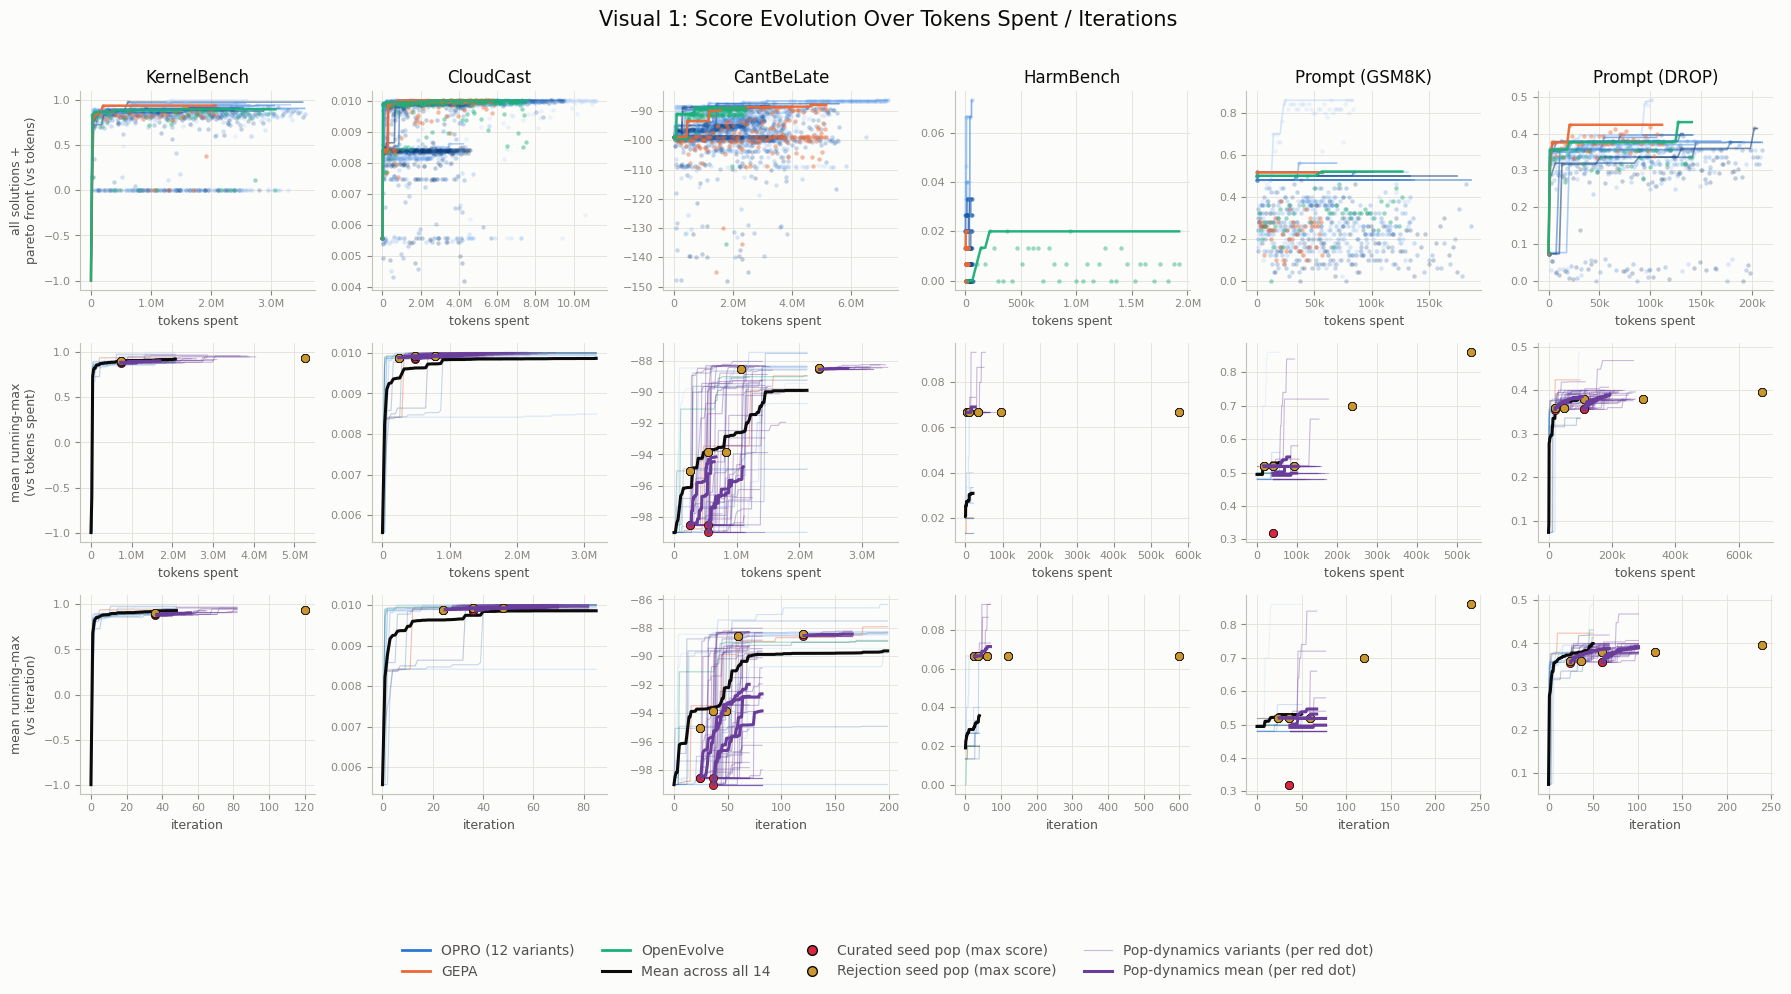

In [ ]:
"""Build the 3x6 Visual 1 figure: score evolution over tokens spent / iterations."""

fig, axes = plt.subplots(
    3, 6, figsize=(18, 9), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    optimizers = runs_by_column[column_key]
    task_name = task_for_column(column_key)
    failed_score = TASK_FAILED_SCORE.get(task_name)
    curated_points = curated_points_by_task.get(column_key, [])
    strategy_points = strategy_points_by_task.get(
        column_key, {'tournament': [], 'rejection': []},
    )

    # --- Per-optimizer trajectories: tokens, raw score, running-max score ---
    trajectories = {}
    for optimizer_label, records in optimizers.items():
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        scores = np.array([r['score'] for r in records], dtype=float)
        trajectories[optimizer_label] = (tokens, scores, running_max(scores))

    # ================= Row 1: scatter + pareto front (vs tokens) =================
    # Sentinel failed-candidate scores (see TASK_FAILED_SCORE) are dropped
    # from the scatter -- they're a crash marker, not a real score, and
    # left in they'd blow out the y-axis range. The pareto front itself
    # (running_max) is untouched: a sentinel is always far below any real
    # score, so it was never going to be selected as the running max anyway.
    ax = axes[0, col_idx]
    ax.set_facecolor(SURFACE)
    for optimizer_label, (tokens, scores, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        valid = scores != failed_score if failed_score is not None else slice(None)
        ax.scatter(
            tokens[valid], scores[valid], s=10, color=color,
            alpha=0.25 if is_opro else 0.45, linewidths=0,
            zorder=2 if is_opro else 3,
        )
        # Pareto front: plot cummax across EVERY token position (not just
        # the points where a new max was set) -- cummax is already flat
        # between improvements, so this draws the correct step function
        # (flat / jump up / flat...) and, as a side effect, means a run
        # whose first (seed) candidate is never beaten still draws as a
        # flat line spanning its whole duration instead of vanishing.
        # Plotting only the breakpoints (the old `scores >= cummax` mask)
        # rendered nothing at all in that single-breakpoint case -- a
        # 1-point line has no segment to draw, even though the scatter
        # above still shows all of that run's dots.
        ax.plot(
            tokens, cummax,
            color=color, linewidth=1.2 if is_opro else 1.8,
            alpha=0.55 if is_opro else 0.95,
            zorder=2 if is_opro else 4,
        )
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    # ================= Row 2: mean running-max vs tokens spent =================
    grid_end = min(t.max() for t, _, _ in trajectories.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    ax = axes[1, col_idx]
    ax.set_facecolor(SURFACE)
    interpolated = []
    for optimizer_label, (tokens, _scores, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # --- Curated seed-population overlay: one red dot per saved
    # Row_i_Col_j.json population (whichever columns actually have content
    # under curated_initial_populations_by_iter_budget/ -- currently all 6,
    # see the loader cell above), at (token cost of the budget that
    # produced it, that population's own best score). Several populations
    # share the same budget -> same x, different y, so they render as a
    # small vertical cluster per budget. ---
    if curated_points:
        ax.scatter(
            [p['cost_tokens'] for p in curated_points],
            [p['max_score'] for p in curated_points],
            color=COLOR_CURATED_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=6,
        )

    # --- Diversity-rejection seed-population overlay: mustard dots, same x
    # definition as the red dots above (same budget -> same token cost,
    # this strategy pools from the same opro runs) -- score-only, no
    # population-dynamics continuation (see the loader cell above: no
    # rollouts seeded from these populations exist yet). Tournament
    # populations are loaded by the same cell but intentionally not
    # plotted here. ---
    if strategy_points['rejection']:
        ax.scatter(
            [p['cost_tokens'] for p in strategy_points['rejection']],
            [p['max_score'] for p in strategy_points['rejection']],
            color=COLOR_REJECTION_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=6,
        )

    # --- Population-dynamics continuation, per red dot: thin dark-purple
    # line per available opro variant (post-seed portion only, see the
    # loader cell above), plus one bold opaque dark-purple mean-of-
    # running-max line -- same interpolation mechanics as the black mean
    # line above, computed independently per red dot since each one's
    # variants start from a different (cost_tokens) offset. ---
    for point in curated_points:
        variants = point['variants']
        if not variants:
            continue
        for variant in variants:
            ax.plot(
                variant['tokens'], variant['scores'],
                color=COLOR_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
            )
        pd_grid_end = min(v['tokens'].max() for v in variants)
        pd_grid = (
            np.linspace(point['cost_tokens'], pd_grid_end, 100)
            if pd_grid_end > point['cost_tokens']
            else np.array([point['cost_tokens']])
        )
        pd_interpolated = [
            step_interpolate(v['tokens'], v['scores'], pd_grid) for v in variants
        ]
        pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)
        ax.plot(
            pd_grid, pd_mean, color=COLOR_POP_DYNAMICS, linewidth=2.2, zorder=7,
        )

    # ================= Row 3: mean running-max vs iteration index =================
    # Same running-max quantity as row 2, but x is the iteration/eval count
    # instead of tokens spent -- iteration index already aligns 1:1 across
    # optimizers (no step-interpolation needed), so this isolates "does
    # convergence-per-iteration differ" from row 2's "convergence-per-token".
    min_len = min(len(cummax) for _, _, cummax in trajectories.values())
    iter_grid = np.arange(min_len)

    ax = axes[2, col_idx]
    ax.set_facecolor(SURFACE)
    iter_series = []
    for optimizer_label, (_tokens, _scores, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        clipped = cummax[:min_len]
        iter_series.append(clipped)
        ax.plot(
            iter_grid, clipped, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_iter_series = np.mean(np.vstack(iter_series), axis=0)
    ax.plot(iter_grid, mean_iter_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # --- Curated seed-population overlay, same points as row 2, but x is
    # iter_cost = budget * num_trajectories_pooled (see the loader cell
    # above) instead of tokens: a budget-N pool was built from N
    # iterations pooled across ~12 independent trajectories, so the
    # iteration-equivalent cost is N * 12, not N -- mirrors row 2's
    # cost_tokens, which is likewise summed across every pooled
    # trajectory rather than reporting just one. ---
    if curated_points:
        ax.scatter(
            [p['iter_cost'] for p in curated_points],
            [p['max_score'] for p in curated_points],
            color=COLOR_CURATED_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=6,
        )

    # --- Diversity-rejection seed-population overlay, same points/color as
    # row 2's block above, but x is iter_cost instead of cost_tokens. ---
    if strategy_points['rejection']:
        ax.scatter(
            [p['iter_cost'] for p in strategy_points['rejection']],
            [p['max_score'] for p in strategy_points['rejection']],
            color=COLOR_REJECTION_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=6,
        )

    # --- Population-dynamics continuation, same points/mean-line logic as
    # row 2's block above, but x is red_dot.iter_cost + local new-solution
    # index (1-indexed) instead of tokens. ---
    for point in curated_points:
        variants = point['variants']
        if not variants:
            continue
        for variant in variants:
            ax.plot(
                variant['iters'], variant['scores'],
                color=COLOR_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
            )
        pd_min_len = min(len(v['scores']) for v in variants)
        pd_iter_grid = point['iter_cost'] + np.arange(1, pd_min_len + 1)
        pd_iter_series = np.vstack([v['scores'][:pd_min_len] for v in variants])
        pd_iter_mean = np.mean(pd_iter_series, axis=0)
        ax.plot(
            pd_iter_grid, pd_iter_mean, color=COLOR_POP_DYNAMICS,
            linewidth=2.2, zorder=7,
        )

    # ================= Shared per-column axis styling =================
    for row_idx in range(3):
        ax = axes[row_idx, col_idx]
        if row_idx in (0, 1):
            ax.xaxis.set_major_formatter(tokens_fmt)
            ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
        else:
            ax.set_xlabel('iteration', color=INK_SECONDARY, fontsize=9)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

ROW_LABELS = [
    'all solutions +\npareto front (vs tokens)',
    'mean running-max\n(vs tokens spent)',
    'mean running-max\n(vs iteration)',
]
for row_idx, label in enumerate(ROW_LABELS):
    axes[row_idx, 0].set_ylabel(label, color=INK_SECONDARY, fontsize=9)

# --- One shared legend: 12 OPRO variants collapse to a single swatch,
# per the color-plan (they're a family, not individually legible). Curated
# seed-population dots, the diversity-rejection seed-population dots, and
# the red dots' population-dynamics continuations (rows 2-3 only) each get
# their own entry. Tournament populations are loaded but not plotted, so
# they intentionally have no legend entry here. ---
legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO (12 variants)'),
    plt.Line2D([0], [0], color=COLOR_GEPA, lw=2, label='GEPA'),
    plt.Line2D([0], [0], color=COLOR_OPEN_EVOLVE, lw=2, label='OpenEvolve'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across all 14'),
    plt.Line2D(
        [0], [0], marker='o', color='none', markerfacecolor=COLOR_CURATED_POP,
        markeredgecolor=INK_PRIMARY, markersize=7,
        label='Curated seed pop (max score)',
    ),
    plt.Line2D(
        [0], [0], marker='o', color='none', markerfacecolor=COLOR_REJECTION_POP,
        markeredgecolor=INK_PRIMARY, markersize=7,
        label='Rejection seed pop (max score)',
    ),
    plt.Line2D(
        [0], [0], color=COLOR_POP_DYNAMICS, lw=0.8, alpha=0.35,
        label='Pop-dynamics variants (per red dot)',
    ),
    plt.Line2D(
        [0], [0], color=COLOR_POP_DYNAMICS, lw=2.2,
        label='Pop-dynamics mean (per red dot)',
    ),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    'Visual 1: Score Evolution Over Tokens Spent / Iterations',
    color=INK_PRIMARY, fontsize=15, y=1.01,
)
fig.tight_layout(rect=(0, 0.08, 1, 1))

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'visual1_score_evolution.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "visual1_score_evolution.pdf")}')

plt.show()


## Visual 2: semantic diversity evolution

Same 3x6 grid and columns as Visual 1. Diversity metric: windowed average
pairwise cosine **distance** across the last 5 discovered solutions (a
sliding window over chronological history, not the live population) --
code tasks (kernelbench, cloudcast, cantbelate) embedded with
`Qodo/Qodo-Embed-1-1.5B`, text tasks (harmbench, prompt+gsm8k, prompt+drop)
with `all-MiniLM-L6-v2`.

**Row treatment differs from Visual 1 on purpose**: diversity has no
"higher is strictly better, take the running max" framing the way score
does, so all three rows plot the **raw windowed-diversity trajectory**
(no running-max/pareto transform anywhere) -- row 1 is the raw scatter +
raw trajectory line per config, rows 2-3 are the mean of those raw
trajectories vs. tokens spent / iteration index, same as before.

**Embedding cache**: `embedding_cache/*.pkl` already had partial coverage
for some columns (reused here, e.g. `all-MiniLM-L6-v2` for prompt_drop
already had the seed candidate's embedding cached) -- missing texts get
embedded and the cache extended, so a second run of the embedding cell is
instant. The code-task columns run several thousand snippets through a
1.5B-param model with no coverage yet, so the first run of that cell is
the slow step in this notebook -- expect real wall-clock time there.


In [ ]:
"""Embedding cache loader + windowed semantic-diversity helper."""

import pickle

import torch
from sentence_transformers import SentenceTransformer

CODE_TASKS = {'kernelbench', 'cloudcast', 'cantbelate'}
CODE_EMBED_MODEL = 'Qodo/Qodo-Embed-1-1.5B'
TEXT_EMBED_MODEL = 'all-MiniLM-L6-v2'
EMBEDDING_CACHE_DIR = '../embedding_cache'
DIVERSITY_WINDOW = 5
EMBED_MAX_SEQ_LENGTH = 4096  # see get_or_build_embeddings docstring


def embed_model_for(column_key: str) -> str:
    """Code embedding model for code tasks, sentence model for text tasks."""
    return CODE_EMBED_MODEL if task_for_column(column_key) in CODE_TASKS else TEXT_EMBED_MODEL


def cache_path_for(column_key: str, model_name: str) -> str:
    filename = f"{column_key}__{model_name.replace('/', '__')}.pkl"
    return os.path.join(EMBEDDING_CACHE_DIR, filename)


def get_or_build_embeddings(
    column_key: str,
    texts: set[str],
    chunk_size: int = 64,
    batch_size: int = 8,
) -> dict[str, np.ndarray]:
    """Load cached embeddings for `texts`, computing + caching what's missing.

    Cache format matches the pre-existing embedding_cache/*.pkl files --
    dict[solution_text, np.ndarray] -- some columns already had partial
    coverage from earlier work, reused here rather than rebuilt from
    scratch.

    Encodes in small chunks, saving the cache to disk after each one.
    Qodo-Embed-1-1.5B's model card calls for flash_attn (not installed in
    this venv), so without it self-attention memory scales quadratically
    with sequence length -- kernelbench solutions run up to ~14k chars
    (~4k tokens), and the original batch_size=32/eager-attention/fp32
    combo was enough to OOM-kill the whole kernel process outright (an
    unclean CUDA OOM, not a catchable Python exception) with zero
    progress saved. fp16 + a capped max_seq_length + a small batch_size
    bound peak memory per batch; sorting missing texts shortest-first
    means a batch never randomly clusters several of the longest
    sequences together (the worst case for a spike); and saving after
    every chunk means a future crash only loses the in-flight chunk
    instead of the whole column.
    """
    model_name = embed_model_for(column_key)
    cache_path = cache_path_for(column_key, model_name)
    os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

    cache: dict[str, np.ndarray] = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)

    missing = sorted(texts - cache.keys(), key=len)
    if not missing:
        print(f'[{column_key}] {len(texts)} texts, all cached.')
        return cache

    print(
        f'[{column_key}] embedding {len(missing)} new / {len(texts)} '
        f'total texts with {model_name}...',
    )
    model = SentenceTransformer(
        model_name,
        model_kwargs={'torch_dtype': torch.float16},
    )
    model.max_seq_length = min(model.max_seq_length, EMBED_MAX_SEQ_LENGTH)

    for start in range(0, len(missing), chunk_size):
        chunk = missing[start : start + chunk_size]
        new_embeddings = model.encode(
            chunk, batch_size=batch_size, show_progress_bar=False,
            convert_to_numpy=True,
        )
        cache.update(zip(chunk, new_embeddings, strict=True))
        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'  [{column_key}] {min(start + chunk_size, len(missing))}'
            f'/{len(missing)} embedded and saved',
        )

    del model
    torch.cuda.empty_cache()
    return cache


def windowed_diversity(
    texts: list[str],
    embeddings: dict[str, np.ndarray],
    window: int = DIVERSITY_WINDOW,
) -> np.ndarray:
    """Average pairwise cosine distance across the last `window` solutions.

    Returns an array aligned to texts[window - 1:] -- shorter than `texts`
    itself, since there's no diversity value until `window` solutions
    exist. Duplicate solution text (e.g. open_evolve's islands
    re-proposing the same code -- see the loader markdown above) is left
    in deliberately, same no-dedup stance as Visual 1: a duplicate in the
    window contributes a real 0-distance pair, which is honest signal
    about how much of the window is actually novel.
    """
    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)

    pair_mask = ~np.eye(window, dtype=bool)
    diversity = np.empty(len(texts) - window + 1)
    for out_idx, i in enumerate(range(window - 1, len(texts))):
        w = unit[i - window + 1 : i + 1]
        sims = w @ w.T
        diversity[out_idx] = 1.0 - sims[pair_mask].mean()
    return diversity


In [ ]:
"""Build/load embeddings for every unique solution text per column.

Slow on the first run (code-task columns have thousands of uncached
snippets going through a 1.5B-param model) -- instant after, since results
are cached to embedding_cache/*.pkl.
"""

embeddings_by_column: dict[str, dict[str, np.ndarray]] = {}
for column_key in COLUMN_ORDER:
    all_texts = {
        r['solution']
        for records in runs_by_column[column_key].values()
        for r in records
    }
    embeddings_by_column[column_key] = get_or_build_embeddings(
        column_key, all_texts,
    )


[kernelbench] 694 texts, all cached.
[cloudcast] 2475 texts, all cached.
[cantbelate] 2714 texts, all cached.
[harmbench] 672 texts, all cached.
[prompt_gsm8k] 612 texts, all cached.
[prompt_drop] 697 texts, all cached.


In [ ]:
"""Compute windowed diversity trajectories per (column, optimizer)."""

# diversity_by_column[column_key][optimizer_label] = (tokens, diversity)
# tokens/diversity are aligned arrays of length len(records) - (window - 1).
diversity_by_column: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}

for column_key in COLUMN_ORDER:
    embeddings = embeddings_by_column[column_key]
    per_optimizer = {}
    for optimizer_label, records in runs_by_column[column_key].items():
        texts = [r['solution'] for r in records]
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        diversity = windowed_diversity(texts, embeddings)
        aligned_tokens = tokens[DIVERSITY_WINDOW - 1 :]
        per_optimizer[optimizer_label] = (aligned_tokens, diversity)
    diversity_by_column[column_key] = per_optimizer

print('diversity trajectories computed for:')
for column_key, per_optimizer in diversity_by_column.items():
    lengths = [len(d) for _, d in per_optimizer.values()]
    print(f'  {column_key:14s} {len(per_optimizer)} optimizers, trajectory length {min(lengths)}-{max(lengths)}')


diversity trajectories computed for:
  kernelbench    14 optimizers, trajectory length 45-47
  cloudcast      14 optimizers, trajectory length 82-197
  cantbelate     14 optimizers, trajectory length 196-197
  harmbench      14 optimizers, trajectory length 36-47
  prompt_gsm8k   14 optimizers, trajectory length 47-47
  prompt_drop    14 optimizers, trajectory length 47-47


/scratch/mansisak/tmp/ipykernel_1994226/4062684787.py:45: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/visual2_diversity_evolution.pdf


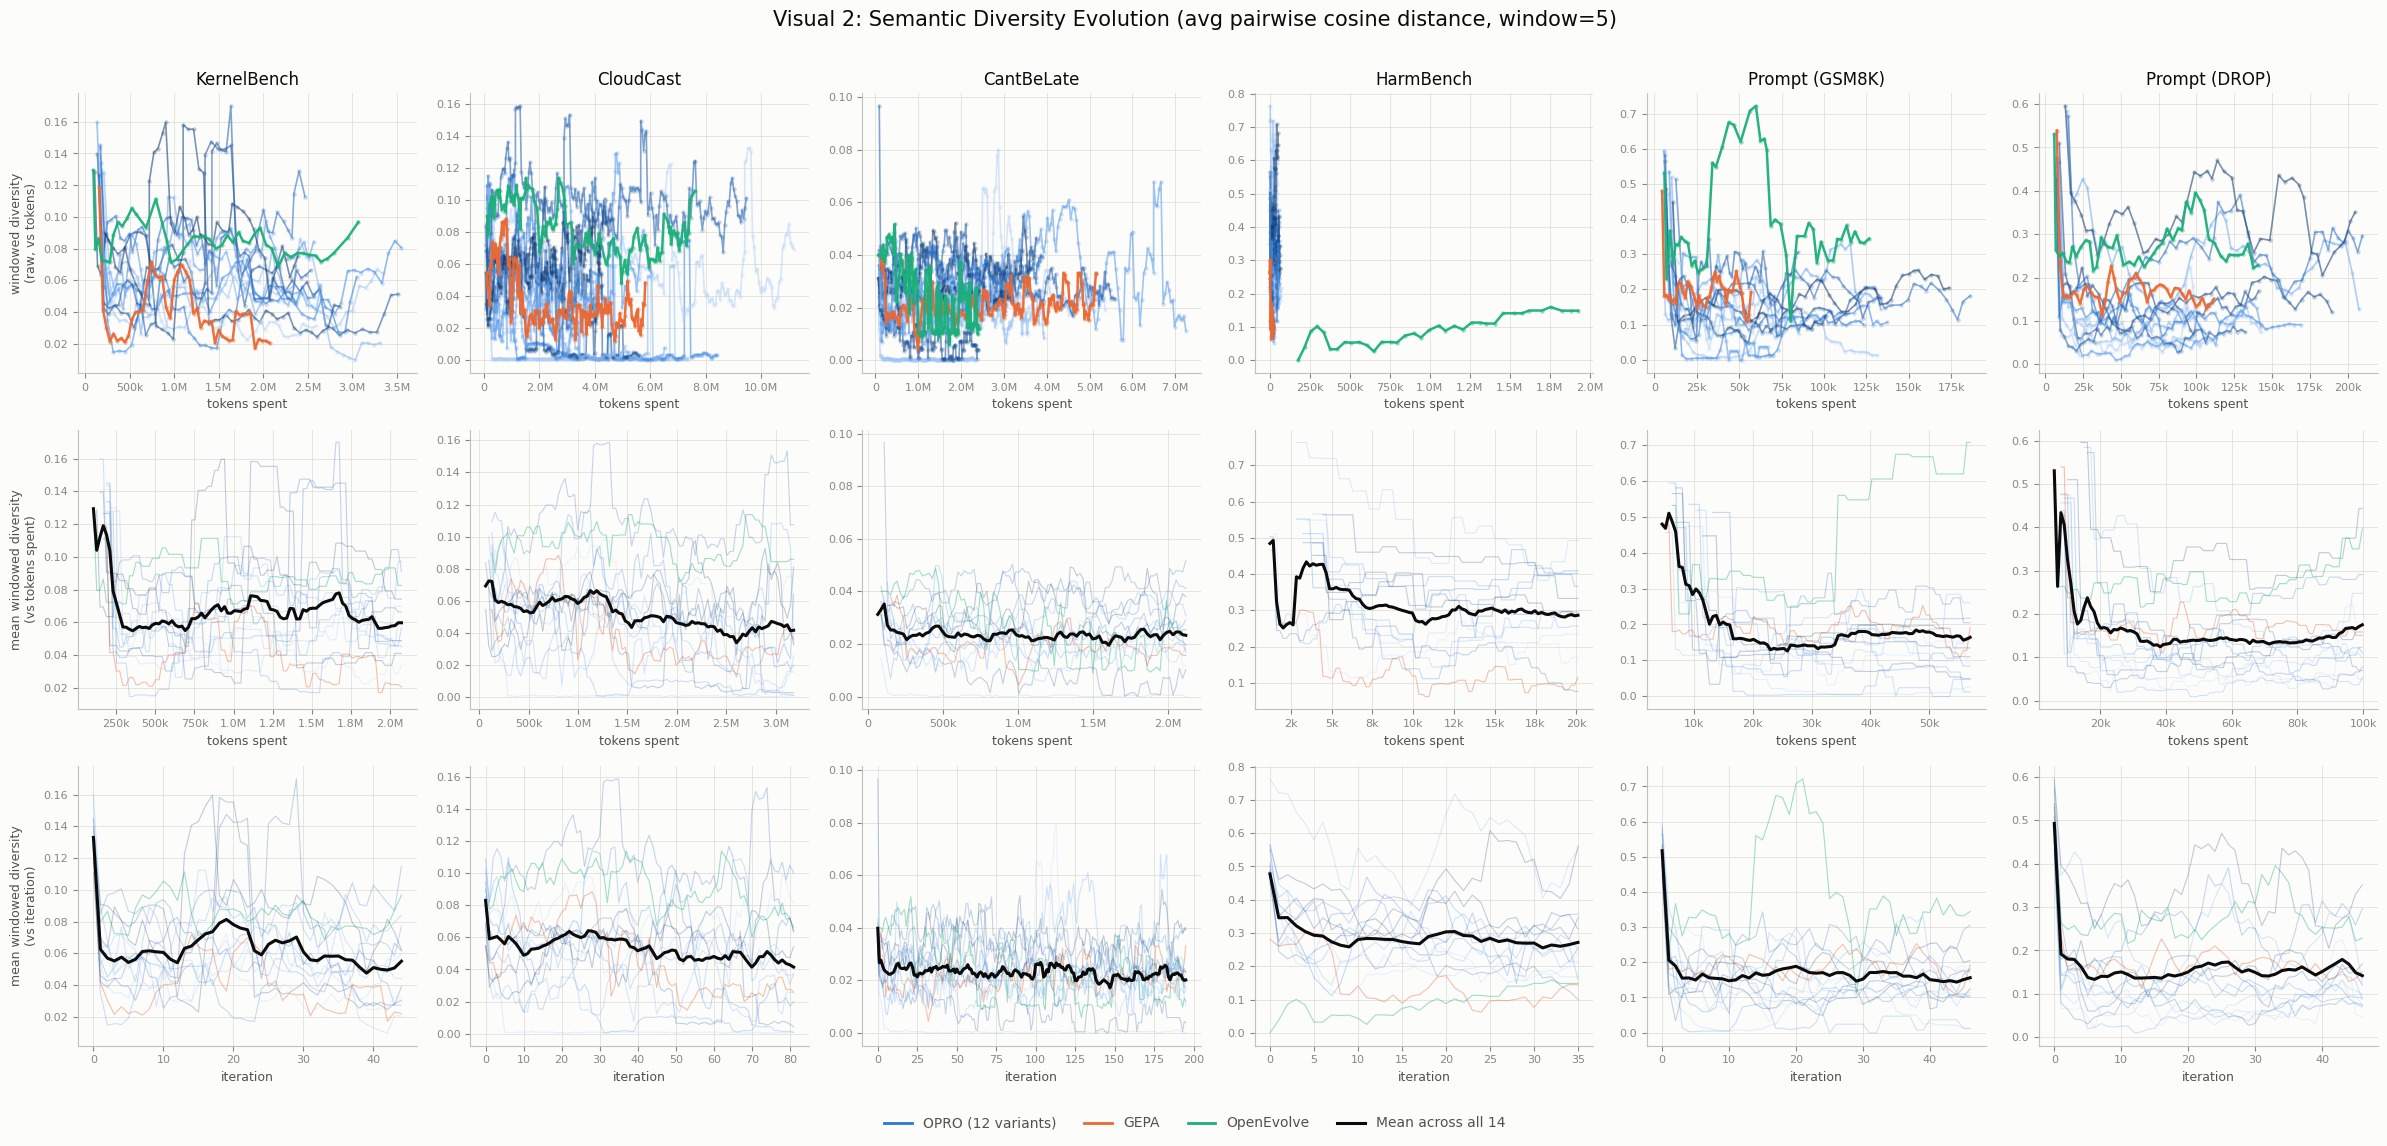

In [ ]:
"""Build the 3x6 Visual 2 figure: semantic diversity evolution."""

fig, axes = plt.subplots(
    3, 6, figsize=(24, 11), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    per_optimizer = diversity_by_column[column_key]

    # ================= Row 1: raw scatter + raw trajectory (vs tokens) =================
    ax = axes[0, col_idx]
    ax.set_facecolor(SURFACE)
    for optimizer_label, (tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        ax.scatter(
            tokens, diversity, s=10, color=color,
            alpha=0.25 if is_opro else 0.45, linewidths=0,
            zorder=2 if is_opro else 3,
        )
        ax.plot(
            tokens, diversity, color=color,
            linewidth=1.2 if is_opro else 1.8,
            alpha=0.55 if is_opro else 0.95,
            zorder=2 if is_opro else 4,
        )
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    # ================= Row 2: mean raw diversity vs tokens spent =================
    grid_end = min(t.max() for t, _ in per_optimizer.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    ax = axes[1, col_idx]
    ax.set_facecolor(SURFACE)
    interpolated = []
    for optimizer_label, (tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        resampled = step_interpolate(tokens, diversity, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # ================= Row 3: mean raw diversity vs iteration index =================
    min_len = min(len(d) for _, d in per_optimizer.values())
    iter_grid = np.arange(min_len)

    ax = axes[2, col_idx]
    ax.set_facecolor(SURFACE)
    iter_series = []
    for optimizer_label, (_tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        clipped = diversity[:min_len]
        iter_series.append(clipped)
        ax.plot(
            iter_grid, clipped, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_iter_series = np.mean(np.vstack(iter_series), axis=0)
    ax.plot(iter_grid, mean_iter_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # ================= Shared per-column axis styling =================
    for row_idx in range(3):
        ax = axes[row_idx, col_idx]
        if row_idx in (0, 1):
            ax.xaxis.set_major_formatter(tokens_fmt)
            ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
        else:
            ax.set_xlabel('iteration', color=INK_SECONDARY, fontsize=9)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

ROW_LABELS = [
    'windowed diversity\n(raw, vs tokens)',
    'mean windowed diversity\n(vs tokens spent)',
    'mean windowed diversity\n(vs iteration)',
]
for row_idx, label in enumerate(ROW_LABELS):
    axes[row_idx, 0].set_ylabel(label, color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO (12 variants)'),
    plt.Line2D([0], [0], color=COLOR_GEPA, lw=2, label='GEPA'),
    plt.Line2D([0], [0], color=COLOR_OPEN_EVOLVE, lw=2, label='OpenEvolve'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across all 14'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'Visual 2: Semantic Diversity Evolution '
    '(avg pairwise cosine distance, window=5)',
    color=INK_PRIMARY, fontsize=15, y=1.01,
)
fig.tight_layout(rect=(0, 0.02, 1, 1))

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'visual2_diversity_evolution.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "visual2_diversity_evolution.pdf")}')

plt.show()
